<a href="https://colab.research.google.com/github/ebenezerjenova-gif/AI-Student-Support/blob/main/AI_Network_Intrusion_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 21.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Download NSL-KDD dataset
!wget -O KDDTrain.txt "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
!wget -O KDDTest.txt "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

print("Dataset downloaded successfully!")

--2026-09-24 08:21:45--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain.txt’

KDDTrain.txt        100%[===================>]  18.22M  --.-KB/s    in 0.1s    

2026-09-24 08:21:45 (165 MB/s) - ‘KDDTrain.txt’ saved [19109424/19109424]

--2026-09-24 08:21:45--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3441513 (3.3M) [text/plain]
Savi

In [ ]:
columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'KDDTest.txt', 'KDDTrain.txt', 'sample_data']


In [ ]:
train_df = pd.read_csv(
    "/content/KDDTrain.txt",
    names=columns
)

test_df = pd.read_csv(
    "/content/KDDTest.txt",
    names=columns
)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (125973, 43)
Testing shape: (22544, 43)


In [ ]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
print("Missing values:")
print(train_df.isnull().sum().sum())

Missing values:
0


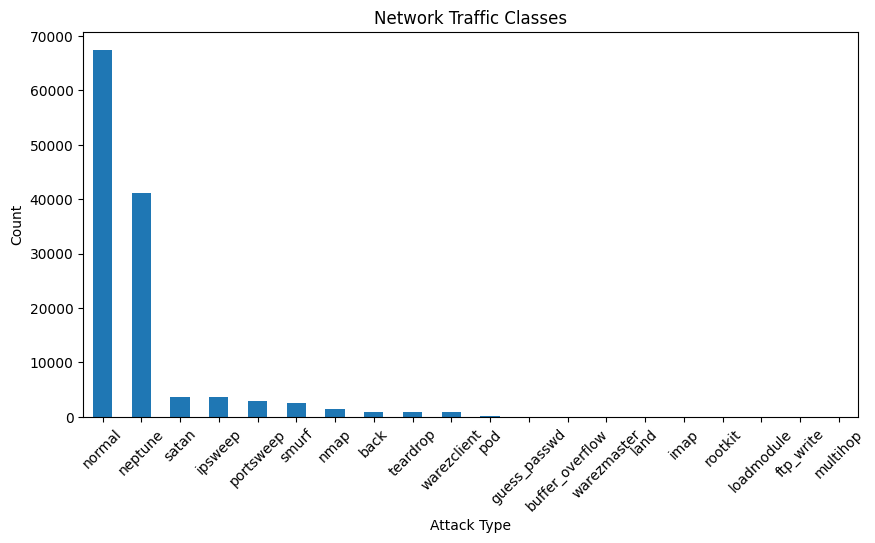

In [ ]:
plt.figure(figsize=(10, 5))

train_df["label"].value_counts().head(20).plot(kind="bar")

plt.title("Network Traffic Classes")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
train_df["target"] = train_df["label"].apply(
    lambda x: 0 if str(x).lower() == "normal" else 1
)

test_df["target"] = test_df["label"].apply(
    lambda x: 0 if str(x).lower() == "normal" else 1
)
print(train_df["target"].value_counts())

print("\nTarget labels:")
print(train_df["target"].value_counts().rename({
    0: "Normal",
    1: "Attack"
}))

target
0    67343
1    58630
Name: count, dtype: int64

Target labels:
target
Normal    67343
Attack    58630
Name: count, dtype: int64


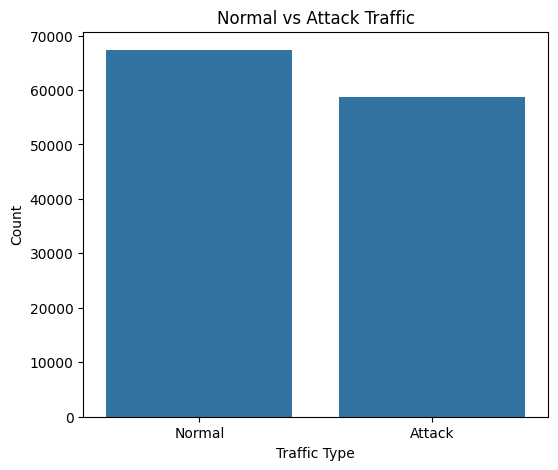

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(
    x=train_df["target"].map({
        0: "Normal",
        1: "Attack"
    })
)

plt.title("Normal vs Attack Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.show()

In [ ]:
X_train = train_df.drop(
    columns=["label", "difficulty", "target"]
)

y_train = train_df["target"]

X_test = test_df.drop(
    columns=["label", "difficulty", "target"]
)

y_test = test_df["target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (125973, 41)
y_train: (125973,)
X_test: (22544, 41)
y_test: (22544,)


In [ ]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['protocol_type', 'service', 'flag']

Numerical features:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

In [ ]:
print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Training completed!")

Training Random Forest...
Training completed!


In [ ]:
rf_predictions = rf_pipeline.predict(X_test)

rf_probabilities = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Predictions completed!")

Predictions completed!


In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Results")
print("----------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Results
----------------------
Accuracy : 0.7674
Precision: 0.9677
Recall   : 0.6118
F1 Score : 0.7496
ROC-AUC  : 0.9611


In [ ]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Normal",
            "Attack"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



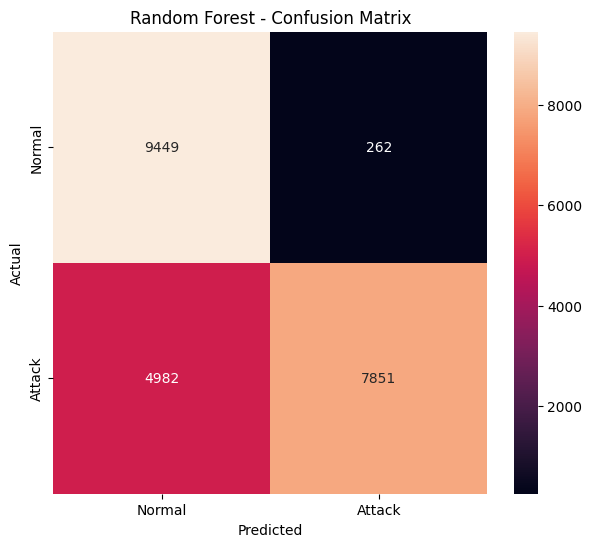

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal",
        "Attack"
    ],
    yticklabels=[
        "Normal",
        "Attack"
    ]
)

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", lr_model)
    ]
)

In [ ]:
print("Training Logistic Regression...")

lr_pipeline.fit(
    X_train,
    y_train
)

print("Training completed!")

Training Logistic Regression...
Training completed!


In [ ]:
lr_predictions = lr_pipeline.predict(X_test)

lr_probabilities = lr_pipeline.predict_proba(
    X_test
)[:, 1]

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions
)

lr_recall = recall_score(
    y_test,
    lr_predictions
)

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

lr_auc = roc_auc_score(
    y_test,
    lr_probabilities
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.7540
Precision: 0.9168
Recall   : 0.6246
F1 Score : 0.7430
ROC-AUC  : 0.7904


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy": [
        rf_accuracy,
        lr_accuracy
    ],

    "Precision": [
        rf_precision,
        lr_precision
    ],

    "Recall": [
        rf_recall,
        lr_recall
    ],

    "F1 Score": [
        rf_f1,
        lr_f1
    ],

    "ROC-AUC": [
        rf_auc,
        lr_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.767388,0.967706,0.611782,0.749642,0.961126
1,Logistic Regression,0.754037,0.916838,0.624562,0.742990,0.790375


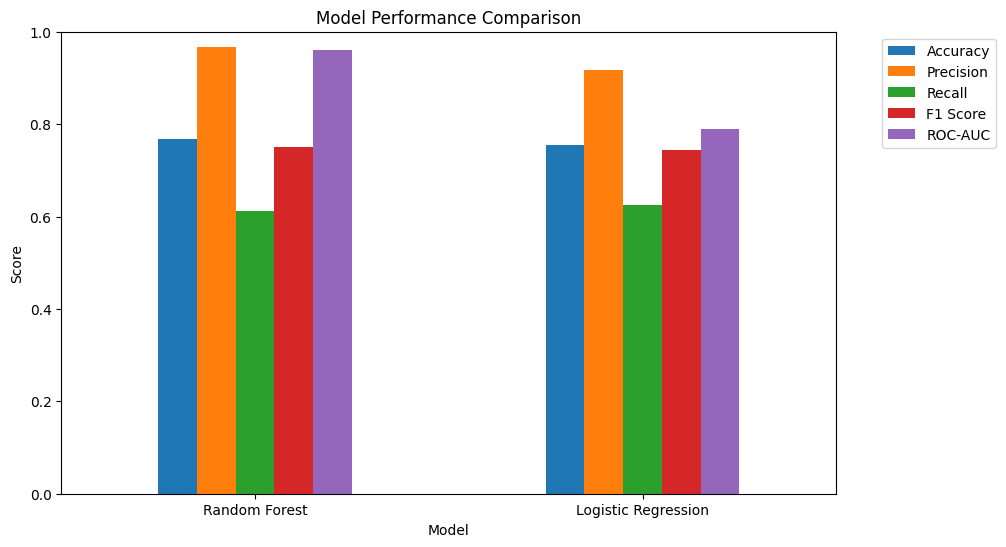

In [ ]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [ ]:
final_model = rf_pipeline

print("Final model selected: Random Forest")

Final model selected: Random Forest


In [ ]:
MODEL_PATH = "/content/intrusion_model.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Model saved:",
    MODEL_PATH
)

Model saved: /content/intrusion_model.pkl


In [ ]:
loaded_model = joblib.load(
    MODEL_PATH
)

test_predictions = loaded_model.predict(
    X_test.head(10)
)

print(test_predictions)

[1 1 0 1 0 0 0 0 0 0]


In [ ]:
from google.colab import files

files.download(
    "/content/intrusion_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.path.exists("/content/intrusion_model.pkl"))

True


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

print("Gradio version:", gr.__version__)

Gradio version: 6.26.0


In [ ]:
import joblib

MODEL_PATH = "/content/intrusion_model.pkl"

model = joblib.load(MODEL_PATH)

print("AI model loaded successfully!")

AI model loaded successfully!


In [ ]:
import pandas as pd
import numpy as np

def detect_intrusion(file):

    try:

        # -----------------------------
        # READ CSV
        # -----------------------------

        data = pd.read_csv(file)

        original_data = data.copy()

        # -----------------------------
        # REMOVE TARGET COLUMNS
        # -----------------------------

        prediction_data = data.copy()

        columns_to_remove = [
            "label",
            "difficulty",
            "target"
        ]

        for column in columns_to_remove:

            if column in prediction_data.columns:
                prediction_data = prediction_data.drop(
                    columns=[column]
                )

        # -----------------------------
        # GET EXPECTED FEATURES
        # -----------------------------

        expected_features = (
            model.named_steps[
                "preprocessor"
            ].feature_names_in_
        )

        # -----------------------------
        # CHECK MISSING FEATURES
        # -----------------------------

        missing_features = [
            col
            for col in expected_features
            if col not in prediction_data.columns
        ]

        if missing_features:

            return (
                None,
                f"Missing required columns: {missing_features}",
                "ERROR"
            )

        # -----------------------------
        # KEEP CORRECT COLUMN ORDER
        # -----------------------------

        prediction_data = prediction_data[
            expected_features
        ]

        # -----------------------------
        # MODEL PREDICTION
        # -----------------------------

        predictions = model.predict(
            prediction_data
        )

        probabilities = model.predict_proba(
            prediction_data
        )

        # -----------------------------
        # CREATE RESULTS
        # -----------------------------

        results = original_data.copy()

        results["Prediction"] = [
            "INTRUSION"
            if prediction == 1
            else "NORMAL"
            for prediction in predictions
        ]

        results["Confidence (%)"] = (
            probabilities.max(axis=1) * 100
        ).round(2)

        # -----------------------------
        # COUNTS
        # -----------------------------

        total_count = len(predictions)

        normal_count = int(
            np.sum(predictions == 0)
        )

        intrusion_count = int(
            np.sum(predictions == 1)
        )

        # -----------------------------
        # SUMMARY
        # -----------------------------

        summary = f"""
TOTAL TRAFFIC: {total_count}

NORMAL TRAFFIC: {normal_count}

INTRUSIONS: {intrusion_count}
"""

        if intrusion_count > 0:

            status = (
                f"⚠️ {intrusion_count} "
                "POTENTIAL INTRUSION(S) DETECTED"
            )

        else:

            status = (
                "✅ NO POTENTIAL INTRUSIONS DETECTED"
            )

        return (
            results,
            summary,
            status
        )

    except Exception as e:

        return (
            None,
            f"Error: {str(e)}",
            "ERROR"
        )

In [ ]:
result, summary, status = detect_intrusion(
    "/content/sample_network_traffic.csv"
)

print(summary)
print(status)


TOTAL TRAFFIC: 20

NORMAL TRAFFIC: 14

INTRUSIONS: 6

⚠️ 6 POTENTIAL INTRUSION(S) DETECTED


In [ ]:
import gradio as gr

with gr.Blocks(
    title="AI Network Intrusion Detector"
) as demo:

    # --------------------------------
    # HEADER
    # --------------------------------

    gr.Markdown(
        """
        # 🛡️ AI Network Intrusion Detector

        ### Machine Learning Based Network Security System

        Upload network traffic data and the AI model
        will classify each connection as **NORMAL**
        or **INTRUSION**.
        """
    )

    gr.Markdown("---")

    # --------------------------------
    # SYSTEM INFORMATION
    # --------------------------------

    gr.Markdown(
        """
        **Model:** Random Forest
        **Dataset:** NSL-KDD
        **Task:** Binary Classification
        **Classes:** Normal / Attack
        """
    )

    # --------------------------------
    # FILE UPLOAD
    # --------------------------------

    file_input = gr.File(
        label="📂 Upload Network Traffic CSV",
        file_types=[".csv"],
        type="filepath"
    )

    analyze_button = gr.Button(
        "🔍 ANALYZE NETWORK TRAFFIC",
        variant="primary"
    )

    # --------------------------------
    # STATUS
    # --------------------------------

    status_output = gr.Markdown(
        "Upload a CSV file to begin analysis."
    )

    # --------------------------------
    # SUMMARY
    # --------------------------------

    summary_output = gr.Textbox(
        label="📊 Detection Summary",
        lines=5
    )

    # --------------------------------
    # RESULTS
    # --------------------------------

    results_output = gr.Dataframe(
        label="🚨 Detection Results",
        interactive=False
    )

    # --------------------------------
    # BUTTON ACTION
    # --------------------------------

    analyze_button.click(
        fn=detect_intrusion,
        inputs=file_input,
        outputs=[
            results_output,
            summary_output,
            status_output
        ]
    )

    # --------------------------------
    # FOOTER
    # --------------------------------

    gr.Markdown(
        """
        ---
        **AI Network Intrusion Detector**
        Built using Python • Scikit-learn • Random Forest • Gradio
        """
    )

In [ ]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79fd097cff299f4047.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
